In [1]:
# Setup & Imports
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython

from src.utils.config import get_config
from src.utils.db import get_db

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
get_ipython().run_line_magic('matplotlib', 'inline')

# Initialize connections
config = get_config()
db = get_db()

print(f"Environment: {config.environment}")
print(f"Database: Connected")

2026-05-17 17:18:14 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Environment: Environment.DEVELOPMENT
Database: Connected


In [2]:
# Load Predictions

from src.services.prediction_service import PredictionService

service = PredictionService()

2026-05-17 17:18:17 [info     ] Loaded model: xgboost_is_winner from xgboost_winner_20260517_141244.pkl
2026-05-17 17:18:17 [info     ] Loaded model: random_forest from random_forest_points_20260517_141246.pkl
2026-05-17 17:18:17 [info     ] Loaded model: logistic_regression from logistic_regression_top3_20260517_141244.pkl
2026-05-17 17:18:17 [info     ] Loaded model: xgboost_is_top3 from xgboost_top3_20260517_141245.pkl
2026-05-17 17:18:17 [info     ] Loaded model: linear_regression from linear_regression_points_20260517_141245.pkl
2026-05-17 17:18:17 [info     ] Loaded 5 valid models         


In [3]:
# Race Prediction Example
race_id = 1  # Example race

predictions = service.predict_race(race_id=race_id, model_type='xgboost', target='is_winner')

print(f"Predictions for Race {race_id}:")
for i, pred in enumerate(predictions[:5]):
    print(f"{i+1}. {pred.driver_name}: {pred.probability:.1%} ({pred.confidence_tier})")

2026-05-17 17:18:30 [debug    ] sql_query_executing            parameters={'race_id': 1} statement='\n        SELECT DISTINCT driver_id\n        FROM results\n        WHERE race_id = %(race_id)s\n        '
2026-05-17 17:18:31 [debug    ] database_transaction_committed
2026-05-17 17:18:31 [debug    ] sql_query_executing            parameters={'race_id': 1, 'driver_id': 1} statement='\n        SELECT * FROM driver_race_features\n        WHERE race_id = %(race_id)s AND driver_id = %(driver_id)s\n        '
2026-05-17 17:18:32 [debug    ] database_transaction_committed


d:\formula1-race-prediction-project\notebooks\..\src\services\prediction_service.py:182: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


2026-05-17 17:18:32 [debug    ] sql_query_executing            parameters={'driver_id': 1} statement='SELECT forename, surname FROM drivers WHERE driver_id = %(driver_id)s'
2026-05-17 17:18:33 [debug    ] database_transaction_committed
2026-05-17 17:18:33 [debug    ] sql_query_executing            parameters={'race_id': 1, 'driver_id': 2} statement='\n        SELECT * FROM driver_race_features\n        WHERE race_id = %(race_id)s AND driver_id = %(driver_id)s\n        '
2026-05-17 17:18:34 [debug    ] database_transaction_committed


d:\formula1-race-prediction-project\notebooks\..\src\services\prediction_service.py:182: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


2026-05-17 17:18:34 [debug    ] sql_query_executing            parameters={'driver_id': 2} statement='SELECT forename, surname FROM drivers WHERE driver_id = %(driver_id)s'
2026-05-17 17:18:35 [debug    ] database_transaction_committed
2026-05-17 17:18:35 [debug    ] sql_query_executing            parameters={'race_id': 1, 'driver_id': 3} statement='\n        SELECT * FROM driver_race_features\n        WHERE race_id = %(race_id)s AND driver_id = %(driver_id)s\n        '
2026-05-17 17:18:36 [debug    ] database_transaction_committed


...

2026-05-17 17:19:19 [debug    ] sql_query_executing            parameters={'driver_id': 33} statement='SELECT forename, surname FROM drivers WHERE driver_id = %(driver_id)s'
2026-05-17 17:19:19 [debug    ] database_transaction_committed
2026-05-17 17:19:20 [debug    ] sql_query_executing            parameters={'race_id': 1, 'driver_id': 34} statement='\n        SELECT * FROM driver_race_features\n        WHERE race_id = %(race_id)s AND driver_id = %(driver_id)s\n        '
2026-05-17 17:19:20 [debug    ] database_transaction_committed


d:\formula1-race-prediction-project\notebooks\..\src\services\prediction_service.py:182: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


2026-05-17 17:19:21 [debug    ] sql_query_executing            parameters={'driver_id': 34} statement='SELECT forename, surname FROM drivers WHERE driver_id = %(driver_id)s'
2026-05-17 17:19:21 [debug    ] database_transaction_committed
2026-05-17 17:19:22 [debug    ] sql_query_executing            parameters={'race_id': 1, 'driver_id': 35} statement='\n        SELECT * FROM driver_race_features\n        WHERE race_id = %(race_id)s AND driver_id = %(driver_id)s\n        '
2026-05-17 17:19:22 [debug    ] database_transaction_committed


d:\formula1-race-prediction-project\notebooks\..\src\services\prediction_service.py:182: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(0)


2026-05-17 17:19:23 [debug    ] sql_query_executing            parameters={'driver_id': 35} statement='SELECT forename, surname FROM drivers WHERE driver_id = %(driver_id)s'
2026-05-17 17:19:23 [debug    ] database_transaction_committed
Predictions for Race 1:
1. Lando Norris: 95.2% (high)
2. George Russell: 69.3% (medium)
3. Carlos Sainz: 40.8% (low)
4. Max Verstappen: 26.4% (medium)
5. Oscar Piastri: 23.1% (medium)


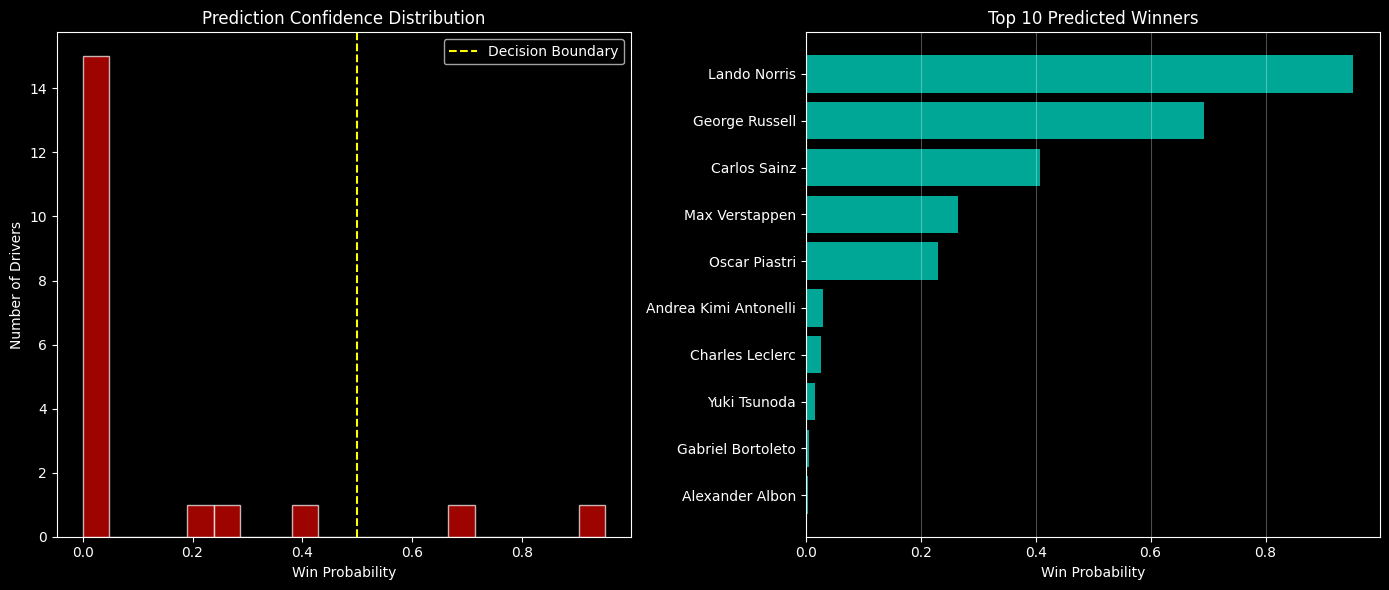

In [6]:
# Prediction Confidence Distribution
probs = [p.probability for p in predictions]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Probability distribution
axes[0].hist(probs, bins=20, color='#e10600', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Win Probability')
axes[0].set_ylabel('Number of Drivers')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].axvline(x=0.5, color='yellow', linestyle='--', label='Decision Boundary')
axes[0].legend()

# Top 10 drivers
top_10 = predictions[:10]
names = [p.driver_name for p in top_10]
probs_top = [p.probability for p in top_10]

axes[1].barh(range(len(names)), probs_top, color='#00d2be', alpha=0.8)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names)
axes[1].invert_yaxis()
axes[1].set_xlabel('Win Probability')
axes[1].set_title('Top 10 Predicted Winners')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# Feature Contribution Analysis
top_prediction = predictions[0]

print(f"\n=== FEATURE CONTRIBUTIONS: {top_prediction.driver_name} ===")
for feature, contribution in sorted(
    top_prediction.feature_contributions.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)[:10]:
    direction = "↑" if contribution > 0 else "↓"
    print(f"{direction} {feature}: {contribution:.6f}")


=== FEATURE CONTRIBUTIONS: Lando Norris ===
↑ constructor_performance_index: 1.294459
↓ starting_position: -0.155059
↓ rolling_avg_finish_pos_5r: -0.043021
↑ driver_performance_index: 0.027763
↑ rolling_avg_points_5r: 0.023006
↑ track_experience_races: 0.022167
↑ recent_form_points: 0.020579
↑ rolling_points_trend: 0.016918
↑ constructor_avg_points_5r: 0.015645
↓ recent_form_finish_pos: -0.013752


In [8]:
import pickle
from pathlib import Path
from datetime import datetime

# Use existing directory
analysis_dir = Path("artifacts/analysis")
analysis_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Collect all analysis variables
analysis_bundle = {}

# Add variables you want to save
variables_to_save = ['comparison', 'points_df', 'importance', 'predictions', 'results']

for var_name in variables_to_save:
    if var_name in locals():
        analysis_bundle[var_name] = locals()[var_name]
        print(f"Packaged {var_name}")

# Save everything in one file
bundle_path = analysis_dir / f"analysis_bundle_{timestamp}.pkl"
with open(bundle_path, 'wb') as f:
    pickle.dump(analysis_bundle, f)

print(f"\nSaved all analysis to: {bundle_path}")
print(f"   Includes: {', '.join(analysis_bundle.keys())}")

✅ Packaged predictions

✅ Saved all analysis to: artifacts\analysis\analysis_bundle_20260517_174701.pkl
   Includes: predictions
